In [ ]:
import os

# Specify the directory path
path = '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train'
pathi= r'/kaggle/input/imagenettxt/WordReport-v1.04.txt'

# Get the immediate subdirectories
subdirectories = next(os.walk(path))[1]
     
print(len(subdirectories))

1000


In [ ]:
with open(pathi, "r") as file: 
    rows = file.readlines()

# Extract the last value of each row
last_values = [row.strip().split()[-1] for row in rows if row.strip()] 

In [16]:
print(last_values[1:10])

['n01744401', 'n02085620', 'n03372029', 'n02120505', 'n02804414', 'n02492035', 'n03710721', 'n02086910', 'n01817953']


In [5]:
count=0
counti=0
usefull=[]
for i in last_values:
    try:
        #print(i,subdirectories.index(i))
        subdirectories.index(i)
        usefull.append(i)
        count+=1
    except: 
        counti+=1
        pass

In [6]:
count,counti

(496, 73)

In [15]:
usefull[1:10]

['n02085620',
 'n03372029',
 'n02120505',
 'n02804414',
 'n02492035',
 'n03710721',
 'n02086910',
 'n01817953',
 'n02107574']

In [ ]:
directory_path = Path(r"/kaggle/input/imageneteeg/MindBigData-Imagenet")

file_names = os.listdir(directory_path)

retained_files = []

for file_name in file_names:
    # Check if any value is in the file name
    if any(value in file_name for value in usefull):
        retained_files.append(file_name)

print(f"Retained {len(retained_files)} files out of {len(file_names)}.")
print("Retained Files:", retained_files[1:10])

        
        

Retained 12202 files out of 14012.
Retained Files: ['MindBigData_Imagenet_Insight_n02134084_3875_1_358.csv', 'MindBigData_Imagenet_Insight_n03782006_14701_1_1164.csv', 'MindBigData_Imagenet_Insight_n03207941_10359_1_675.csv', 'MindBigData_Imagenet_Insight_n04259630_10816_1_905.csv', 'MindBigData_Imagenet_Insight_n02804414_5558_1_30.csv', 'MindBigData_Imagenet_Insight_n02097298_378_1_683.csv', 'MindBigData_Imagenet_Insight_n01558993_2691_1_388.csv', 'MindBigData_Imagenet_Insight_n07742313_2362_1_2585.csv', 'MindBigData_Imagenet_Insight_n02444819_2322_1_369.csv']


In [ ]:
import re

extracted_parts = []

for file_name in file_names:
    if file_name.endswith(".csv"):
        match = re.search(r"n\d+_\d+", file_name)
        if match:
            extracted_parts.append(match.group(0))

print("Extracted Parts:", extracted_parts[1:10])


Extracted Parts: ['n02134084_3875', 'n03782006_14701', 'n03207941_10359', 'n04259630_10816', 'n02804414_5558', 'n02097298_378', 'n02324045_9184', 'n01558993_2691', 'n07742313_2362']


In [18]:
from PIL import Image
import matplotlib.pyplot as plt

def display_extracted_image(extracted_part):

    # Extract category and image ID
    category, image_id = extracted_part.split("_")
    
    # Build the image path
    image_path = os.path.join(path, category, f"{category}_{image_id}.JPEG")
    
    # Check if the file exists
    if os.path.exists(image_path):
        # Open and display the image
        with Image.open(image_path) as img:
            plt.imshow(img)
            plt.axis('off')  # Hide axes for better visualization
            plt.title(f"Image: {category}_{image_id}")
            plt.show()
    else:
        print(f"Image not found: {image_path}")


In [24]:
def count_extracted_image():
    count=0
    counti=0
    for extracted_part in extracted_parts:
        # Extract category and image ID
        category, image_id = extracted_part.split("_")
        
        # Build the image path
        image_path = os.path.join(path, category, f"{category}_{image_id}.JPEG")
        
        # Check if the file exists
        if os.path.exists(image_path):
            count+=1
        else:
            counti+=1
            #print(f"Image not found: {image_path}")
    return count,counti

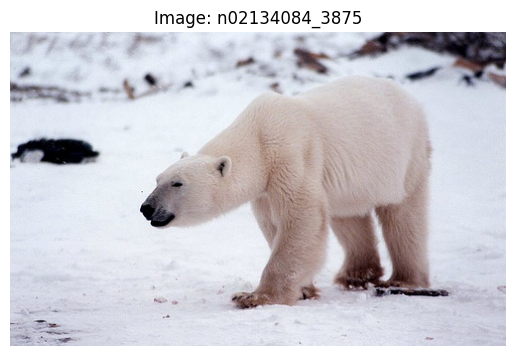

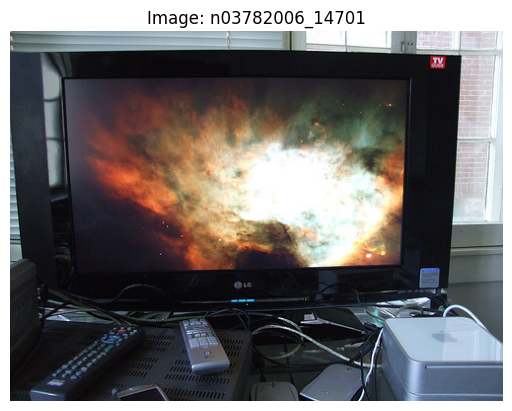

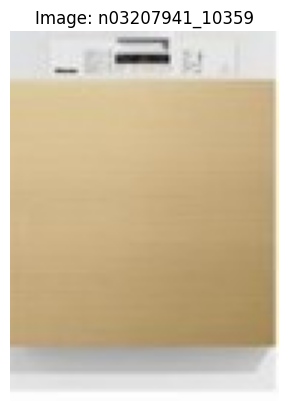

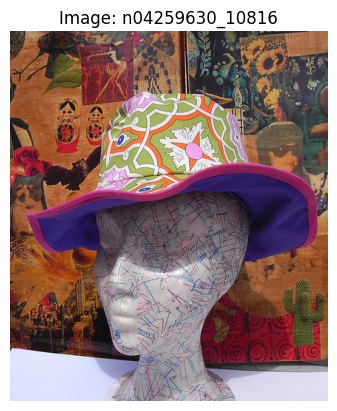

In [26]:
for extracted_part in extracted_parts[1:5]:
    display_extracted_image(extracted_part)

In [25]:
count_extracted_image()

(12199, 1813)

In [29]:
def get_existing_image_paths(extracted_parts):
    existing_image_paths = []
    
    for extracted_part in extracted_parts:
        # Extract category and image ID
        category, image_id = extracted_part.split("_")
        
        # Build the image path
        image_path = os.path.join(path, category, f"{category}_{image_id}.JPEG")
        
        # Check if the file exists
        if os.path.exists(image_path):
            existing_image_paths.append(image_path)
    
    return existing_image_paths

In [30]:
existing_image_paths = get_existing_image_paths(extracted_parts)
existing_image_paths[1:10]

['/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n02134084/n02134084_3875.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n03782006/n03782006_14701.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n03207941/n03207941_10359.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n04259630/n04259630_10816.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n02804414/n02804414_5558.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n02097298/n02097298_378.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n01558993/n01558993_2691.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n07742313/n07742313_2362.JPEG',
 '/kaggle/input/imagenet-object-localization-challenge/ILSVRC/Data/CLS-LOC/train/n02444819/n02

In [ ]:
import shutil
import os

def remove_all_from_dir(dir_path):
    if os.path.exists(dir_path):
        for item in os.listdir(dir_path):
            item_path = os.path.join(dir_path, item)
            
            # If it's a directory, remove it recursively
            if os.path.isdir(item_path):
                shutil.rmtree(item_path)
            # If it's a file, remove it
            else:
                os.remove(item_path)
        print(f"All contents removed from {dir_path}")
    else:
        print(f"Directory {dir_path} does not exist")

remove_all_from_dir(r'/kaggle/working/')


All contents removed from /kaggle/working/


In [ ]:
import shutil
import os

# Function to calculate the total size of a directory
def get_dir_size(dir_path):
    total_size = 0
    for dirpath, dirnames, filenames in os.walk(dir_path):
        for filename in filenames:
            file_path = os.path.join(dirpath, filename)
            total_size += os.path.getsize(file_path)
    return total_size

# Function to download images, check size, and zip if needed
def download_images(target_base_dir, existing_image_paths, size_limit=15 * 1024**3):
    # Create the target base directory if it doesn't exist
    if not os.path.exists(target_base_dir):
        os.makedirs(target_base_dir)

    target_dir = os.path.join(target_base_dir, "images_1")  # Initial directory name
    if not os.path.exists(target_dir):
        os.makedirs(target_dir)

    current_image_count = 1  # Counter for images added in current directory
    
    for image_path in existing_image_paths:
        # Check if the file exists
        if os.path.exists(image_path):
            
            image_id = image_path.split('/')[-1].split('.')[0]

            # Define the target path where the image will be copied
            target_path = os.path.join(target_dir, f"{image_id}.JPEG")
            
            # Copy the image to the target directory
            shutil.copy(image_path, target_path)
            #print(f"Image downloaded: {target_path}")

            # Check the current directory size
            if get_dir_size(target_dir) > size_limit:
                # If size exceeds the limit, zip the directory and reset
                zip_dir_path = f"{target_dir}.zip"
                shutil.make_archive(zip_dir_path, 'zip', target_dir)
                print(f"Directory {target_dir} zipped as {zip_dir_path}")
                
                # Create a new directory and continue adding images
                remove_all_from_dir(target_dir)
                current_image_count += 1
                target_dir = os.path.join(target_base_dir, f"images_{current_image_count}")
                os.makedirs(target_dir)

        else:
            print(f"Image not found: {image_path}")
            
    zip_dir_path = f"{target_dir}"
    shutil.make_archive(zip_dir_path, 'zip', target_dir)
    print(f"Directory {target_dir} zipped as {zip_dir_path}")
    remove_all_from_dir(target_dir)


target_base_dir = '/kaggle/working/'

download_images(target_base_dir, existing_image_paths)



Directory /kaggle/working/images_1 zipped as /kaggle/working/images_1.zip
